<p align="center">
  <img src="./Figures/Label.png"
       alt="MSSE Summer School hands-on session banner"
       width="900">
</p>


# Prediction of Molecular Diffusion Coefficients

<div class="msse-callout"><b>🧭 How to use this notebook</b><br>
GROMACS and Linux commands are shown separately and are intended to be copied into a <b>Linux terminal</b>. MDAnalysis sections are provided as <b>executable Python cells</b> so that trajectory analysis, plotting, fitting, and custom transport calculations can be performed interactively in the notebook.
</div>

> **Visual guide:** 🎯 Purpose · 🔧 Key options · 📥 Inputs · 📤 Outputs · <span style="color:#27AE60"><b>✅ Validation</b></span> · <span style="color:#EB5757"><b>⚠️ Troubleshooting</b></span> · 💡 Scientific note


## 🎯 Objective

This tutorial develops diffusion analysis in **four progressively more realistic examples**:

1. **CO₂ in bulk water** — the foundation example used to learn the complete self-diffusion workflow.
2. **H₂ in bulk brine** — introduces ions, salinity effects, and species-by-species mobility.
3. **H₂ in a water-filled clay slit pore** — introduces confinement, anisotropy, and the limits of a bulk MSD treatment.
4. **Collective diffusion in a bulk gas mixture** — introduces Maxwell–Stefan diffusion from collective molecular motion.


The core observable is the **self-diffusion coefficient** obtained from the mean-squared displacement (MSD) using the Einstein–Smoluchowski relation. The final example then moves to **collective diffusion**.

<p align="center">
  <img src="./Figures/Diff.png"
       alt="Molecular diffusion in bulk and confined systems"
       width="900">
</p>


## 🧭 Workflow at a glance

The teaching narrative is:

```text
Example 1: CO₂ + H₂O
        ↓
learn self-diffusion from MSD
        ↓
Example 2: H₂ + brine
        ↓
add salinity, ions, and local solvation
        ↓
Example 3: H₂ + water + clay
        ↓
add confinement and anisotropy
        ↓
Example 4: H₂ + CO₂ bulk mixture
        ↓
move from self-diffusion to collective Maxwell–Stefan diffusion
```

Across all examples the same discipline is maintained:

1. define the physical state;
2. verify the force field and topology;
3. equilibrate the system;
4. generate an appropriate dynamical trajectory;
5. inspect the transport regime before fitting;
6. report uncertainty and modelling limitations.


## 📁 1. Project organization


<div class="msse-note"><b>💡 Why this section matters</b><br>
The four examples use different compositions and, later, different geometries. Keeping each case isolated prevents coordinates, topologies, trajectories, and fitted transport coefficients from being mixed between examples.</div>


### 📝 Create the working folders

> 🎯 **Purpose:** Keep the four examples separate while preserving the same build → equilibration → production → analysis logic.


```bash
mkdir -p CO2_water_diffusion/{inputs,build,em,equilibration,production,analysis,replicas}
mkdir -p H2_brine_diffusion/{inputs,build,em,equilibration,production,analysis,replicas}
mkdir -p H2_clay_diffusion/{inputs,build,em,equilibration,production,analysis}
mkdir -p multicomponent_bulk_diffusion/{inputs,build,em,equilibration,production,analysis}
```

> 🔧 **Key options:** `mkdir -p` creates the directory tree without failing if folders already exist.
>
> 📥 **Inputs:** None.
>
> 📤 **Outputs / changes:** Four independent example directories.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Run `find . -maxdepth 2 -type d | sort` and confirm that the four case folders are separate.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not reuse a production trajectory from one composition or geometry with the `.tpr` file from another.


Place only the files required for each example into its `inputs/` directory.

**Example 1 — CO₂ in water**
- `CO2.pdb`, `CO2.itp`
- `spce.itp`
- project-local `oplsaa.ff/`
- `em_diff.mdp`, `npt_diff.mdp`, `nvt_diff.mdp`, `nve_diff.mdp`

**Example 2 — H₂ in brine**
- `H2.pdb`, `H2.itp`
- `NA.pdb`, `CL.pdb`
- `spce.itp`, `ions.itp`
- the same validated compatible force-field files

**Example 3 — H₂ in clay**
- a **supplied pre-built clay/water/H₂ starting structure**
- the corresponding clay/mineral topology and compatible water/H₂ force-field files
- equilibration and NVE production MDP files

**Example 4 — collective bulk diffusion**
- `H2.pdb`, `H2.itp`, `CO2.pdb`, `CO2.itp`
- the validated gas force-field files
- equilibration and NVE production MDP files

<div class="msse-warning"><b>⚠️ Do not mix force-field families casually</b><br>
The fact that two `.itp` files can be included in one topology does not demonstrate that their cross interactions form a validated physical model.</div>


## 🧩 2. GROMACS files used in this workflow


<div class="msse-note"><b>💡 Why this section matters</b><br>
Diffusion is obtained from trajectories, but trajectory quality depends on the coordinate, topology, MDP, and checkpoint files that created them.</div>


| File type | Role in this tutorial |
|---|---|
| `.pdb`, `.gro` | Coordinates and box dimensions |
| `.itp` | CO₂, water, ion, and force-field molecule definitions |
| `.top` | Full system topology and molecule counts |
| `.mdp` | Minimization/equilibration/production settings |
| `.tpr` | Binary run input and reference for analysis |
| `.cpt` | Velocities and state required for clean continuation |
| `.edr` | Temperature, pressure, energy, volume, density |
| `.xtc` | Coordinate trajectory used for MSD analysis |
| `.trr` | Full-precision coordinates/velocities if VACF analysis is planned |
| `.xvg` | MSD, RDF, energy, and other analysis output |

```text
coordinates + topology + MDP
             |
             v
         gmx grompp
             |
             v
            TPR
             |
             v
         gmx mdrun
             |
             v
 trajectory + energy + checkpoint
             |
             v
       diffusion analysis
```


### 2.1 Analysis stack used in this tutorial

The simulation and analysis tasks are deliberately separated:

```text
GROMACS
  └─ build → equilibrate → NVE production → TPR + XTC/TRR
                                      │
                                      ▼
                                 MDAnalysis
                      selections · MSD · RDF · density
                    COM trajectories · custom correlations
```

- **GROMACS** remains the main engine for system preparation and molecular dynamics.
- **MDAnalysis** provides an interactive Python layer for interrogating the resulting trajectory.
- The same result is sometimes calculated by both routes so that students can distinguish the **physics** from the software command used to obtain it.


## 🧠 3. Diffusion quantities: what are we calculating?


### 3.1 Self-diffusion

The self-diffusion coefficient describes the motion of molecules of one species arising from thermal molecular motion.

For an isotropic three-dimensional (d=3) bulk fluid,

$$
D_i^{\mathrm{self}}
=
\lim_{t\rightarrow\infty}
\frac{1}{2dt}
\left\langle
\left|
\mathbf r_i(t+t_0)-\mathbf r_i(t_0)
\right|^2
\right\rangle_{i,t_0}.
$$

Define the mean-squared displacement:

$$
\mathrm{MSD}(t)
=
\left\langle
\left|
\mathbf r_i(t+t_0)-\mathbf r_i(t_0)
\right|^2
\right\rangle_{i,t_0}.
$$

Then, in the long-time normal-diffusion regime,

$$
\mathrm{MSD}(t) = 6Dt + C.
$$

Therefore, if the fitted slope is \(m\),

$$
D = \frac{m}{6}.
$$

<div class="msse-warning"><b>⚠️ Central lesson</b><br>
The Einstein relation is not justified merely because an MSD curve exists. The fitting interval must lie in a regime where the MSD is approximately linear in time and where the molecules have sampled a representative length scale.</div>


### 3.2 MSD regimes

A useful diagnostic is

$$
\alpha(t)=
\frac{d\ln(\mathrm{MSD})}{d\ln(t)}.
$$

Typical interpretations are:

| Regime | Approximate behavior |
|---|---|
| Ballistic | $\mathrm{MSD}\propto t^2$, so $\alpha\approx2$ |
| Transitional / sub-diffusive | $0<\alpha<1$ or non-constant slope |
| Normal diffusion | $\mathrm{MSD}\propto t$, so $\alpha\approx1$ |
| Confined/plateauing | MSD tends toward a finite scale |

For the bulk self-diffusion calculation, the fit should be made only after the trajectory reaches the normal-diffusion regime.


<p align="center">
  <img src="./Figures/Diff_regimes.jpg"
       alt="Diffusion regimes"
       width="600">
</p>

### 3.3 Green–Kubo alternative

For a homogeneous bulk fluid, the equivalent Green–Kubo expression is

$$
D_i^{\mathrm{self}}
=
\frac{1}{3}
\int_0^\infty
\left\langle
\mathbf v_i(0)\cdot\mathbf v_i(t)
\right\rangle dt.
$$

This uses the velocity autocorrelation function (VACF). It is included later as an optional extension because it requires sufficiently frequent velocity output and careful convergence of the long-time integral.


As the simulation setup and computational cost are essentially the same for the Green–Kubo and Einstein approaches, the primary difference lies in the post-simulation data analysis. The precision and reproducibility of the estimated values are therefore key considerations when selecting between these two methods. For this reason, particular emphasis should be placed on appropriate and clearly reported data analysis procedures, together with rigorous uncertainty quantification. [Maginn $et\; al$. (2018)]



### 3.4 Self, Maxwell–Stefan, and Fick diffusion are not interchangeable

- **Self-diffusion:** tagged-particle motion at equilibrium. Examples 1–3 focus on this quantity.
- **Maxwell–Stefan diffusion:** collective relative motion/friction between species. Example 4 introduces this quantity.
- **Fick diffusion:** relates species fluxes to concentration gradients.
- **Thermodynamic factor:** connects Maxwell–Stefan and Fick diffusivities in non-ideal mixtures.


<p align="center">
  <img src="./Figures/Diff_regimes_typesn.jpg"
       alt="Diffusion regimes"
       width="600">
</p>


## ⚙️ 4. Force-field organization


<div class="msse-note"><b>💡 Why this section matters</b><br>
Diffusivity is highly sensitive to intermolecular interactions. The force field must therefore be treated as part of the result: gas model, water model, ions, mineral model, mixing rules, and any explicit cross interactions should all be reported.</div>


### 🔍 Inspect the force-field defaults

> 🎯 **Purpose:** Confirm the nonbonded function, combination rule, and 1–4 scaling used by the project-local force field.


```bash
sed -n '1,40p' CO2_water_diffusion/inputs/oplsaa.ff/forcefield.itp
```


> 🔧 **Key options:** `sed -n '1,40p'` prints the first 40 lines without modifying the file.
>
> 📥 **Inputs:** `oplsaa.ff/forcefield.itp`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm the `[ defaults ]` line and the expected include files.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Use the project-local force field rather than an unrelated installed copy.



```text
[ defaults ]
; nbfunc  comb-rule  gen-pairs  fudgeLJ  fudgeQQ
1         2          yes        0.5      0.5
```

Therefore:

- `nbfunc = 1`: Lennard–Jones 12–6 nonbonded interaction;
- `comb-rule = 2`: unlike $\sigma$ values are combined arithmetically and $\epsilon$ values geometrically;
- `fudgeLJ = 0.5`, `fudgeQQ = 0.5`: OPLS-style 1–4 scaling.

Unless explicit gas–water or gas–ion pair parameters are supplied, the combination rule determines the unlike Lennard–Jones interactions.

<div class="msse-warning"><b>⚠️ Scientific check</b><br>
A numerically stable trajectory does not validate a force-field combination. Before using absolute diffusivities, benchmark the selected gas/water/ion model against available experimental or trusted simulation data for a simpler state point.</div>


### 🔍 Confirm the atom types needed by the supplied examples


```bash
# CO2 and H2 types used by the supplied gas models
grep -nE '^\s*(opls_271|opls_272)\b' CO2_water_diffusion/inputs/oplsaa.ff/ffnonbonded.itp

# SPCE water and Na+/Cl- types used in the supplied teaching force field
grep -nE '^\s*opls_(004|966|116|117)\b' H2_brine_diffusion/inputs/oplsaa.ff/ffnonbonded.itp
```

The exact type numbers must match the files distributed with the summer-school package. If the final teaching package uses different validated models, update the checks rather than forcing the topology to match these labels.


> <span style="color:#27AE60"><b>✅ Validation:</b></span> Each required type should appear exactly as expected.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not create duplicate atom-type definitions simply because a molecule is being used in a new tutorial.


## 🧬 5. Topology files

Each example must include the molecule definitions required by that system **after** the force-field defaults/atom types are loaded.

Example 1:

```text
#include "oplsaa.ff/forcefield.itp"
#include "CO2.itp"
#include "spce.itp"
```

Example 2 adds:

```text
#include "H2.itp"
#include "ions.itp"
```

Example 3 additionally requires the **supplied clay/mineral topology**. Example 4 uses the gas-model files for the chosen bulk mixture.


Key checks:

- molecular atom ordering in each `.itp` must match the corresponding coordinate file;
- rigid water geometry and virtual sites must match the solvent coordinate template;
- the `[ molecules ]` section must follow the order of complete molecule blocks in the final coordinate file;
- do not define the same atom type twice;
- do not silently switch water, ion, gas, or clay models between examples.


### 🔍 Inspect the molecular topologies used in Examples 1 and 2


```bash
cat CO2_water_diffusion/inputs/CO2.itp
cat CO2_water_diffusion/inputs/spce.itp

cat H2_brine_diffusion/inputs/H2.itp
cat H2_brine_diffusion/inputs/ions.itp
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm charges, masses, atom order, constraints/SETTLE definitions, and the atom types referenced by each molecule.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> A topology can pass `gmx grompp` and still be scientifically inappropriate. Numerical acceptance is not force-field validation.


## 🧪 6. Define the physical state before building the systems

Before creating coordinates, complete one state-point record for each example. 

| Example | \(T (K)\) | \(P (bar)\) | Composition | Geometry | Main quantity |
|---|---:|---:|---|---|---|
| 1. CO₂–water | `298` | `100` | `CO₂` | cubic bulk | $D_{\mathrm{CO2}}^{self}$ |
| 2. H₂–brine | `323` | `100` | `H₂` | cubic bulk | $D_{\mathrm{H2}}^{self}$, ion/water mobility |
| 3. H₂–clay | `368` | `300` or fixed pore state | supplied water/H₂ loading | slit pore, normal = $z$ | $D_\parallel$, confinement diagnostics |
| 4. H₂–CO₂ | `353` | `200` | `CO₂-H₂` | homogeneous bulk | self + Maxwell–Stefan |

<div class="msse-warning"><b>⚠️ Concentration and sampling are different design questions</b><br>
Adding more gas molecules improves statistics, but also changes composition. If the scientific target is an infinite-dilution self-diffusion coefficient, concentration dependence must be checked.</div>


## ⚙️ 7. System preparation for diffusion calculations

<div class="msse-note"><b>💡 Why this section matters</b><br>
A diffusion coefficient is a <b>dynamical property</b>. Obtaining a stable temperature, pressure, or density is therefore not sufficient: the production trajectory must also preserve the natural molecular dynamics and be long enough for molecules to reach the true diffusive regime.
</div>

### ⚠️ 7.0. Common pitfalls in transport-property simulations 

Reliable transport properties require careful checks of both **energy conservation** and **sampling time**. [Maginn $et\; al$. (2018)]

#### 7.0.1. Energy conservation in NVE

For NVE production runs, the integrator must conserve total energy.

Common causes of energy drift include:

- insufficient numerical precision;
- an excessively large time step;
- poorly maintained bond/angle constraints.

A practical check is to plot the **total energy versus time** while systematically reducing the time step. A well-behaved NVE simulation should show little or no systematic energy drift.

> **Recommendation:** use double precision where possible and verify that any imposed constraints remain satisfied.

---

#### 7.0.2. Simulation time must exceed molecular correlation times

Transport-property expressions assume that the observation time is much longer than the characteristic correlation time of the molecular motion.

This is usually straightforward for simple liquids with fast relaxation, but can become problematic for systems with **slow dynamics**.

A useful convergence test is to perform progressively longer simulations and check whether the calculated transport coefficient changes significantly.

---

#### 7.0.3. Check whether molecules explore enough configuration space

The MSD provides another practical test of whether the simulation is sufficiently long.

Compare

$$
\sqrt{\mathrm{MSD}}
$$

with characteristic system dimensions such as:

- the radius of gyration of the largest molecule, $r_G$;
- the simulation box length, $L$.

Ideally,

$$
\sqrt{\mathrm{MSD}} > r_G
$$

and, for stronger evidence of adequate sampling,

$$
\sqrt{\mathrm{MSD}} \sim L
\quad \text{or larger}.
$$

This indicates that molecules have travelled far enough to explore a substantial portion of configuration space.

---
## 🧩 Force-field combination validation

<div class="msse-note"><b>💡 Key idea</b><br>
A force field that accurately describes a pure component does not necessarily provide an accurate description when it is combined with force fields for other species.

For diffusion calculations, we should therefore validate the <b>complete combination of force fields</b> — including the cross-interactions between species — against reliable experimental or benchmark data whenever possible.
</div>

### Why validate the combination?

Consider a CO₂–brine system. Separate models are required for:

- CO₂;
- water;
- Na⁺ and Cl⁻;
- and the interactions between unlike species.

Even if each individual model performs well for its pure component, the resulting combination may incorrectly predict:

- solution structure;
- density;
- viscosity;
- solubility;
- hydration behaviour;
- and ultimately the diffusion coefficient.

Therefore,

$$
\boxed{
\text{Good individual force fields}
\;\not\Rightarrow\;
\text{good mixture force field}
}
$$

The appropriate force-field combination should be selected based on the **property being studied**, the **composition**, and the **temperature–pressure range** of interest.

### 🔬 A practical validation workflow

Before carrying out a large set of production simulations:

1. **Identify candidate force fields** for each component from the literature.

2. **Construct several physically reasonable combinations** of these models.

3. Check that the models are compatible, including:
   - Lennard–Jones parameters;
   - partial charges;
   - combining rules;
   - water model;
   - ion parameters;
   - constraints and molecular geometry.

4. Choose experimental or high-quality reference data that are sensitive to the physics of interest.

5. Run the candidate combinations under the **same thermodynamic conditions**.

6. Compare predictions quantitatively using metrics such as

$$
\mathrm{AARE},\qquad
\mathrm{RMSE},\qquad
R^2
$$

and consider the statistical uncertainty of the MD simulations.

7. Select the combination that performs reliably across several relevant state points rather than choosing a model based on a single simulation.

<div class="msse-warning"><b>⚠️ No universally "best" force field</b><br>
A combination that reproduces density accurately may not reproduce diffusion, viscosity, solubility or interfacial properties equally well. Validation should therefore reflect the <b>observable that you intend to calculate</b>.
</div>

### 📚 Case study 1 — CO₂ diffusion in brine

**Omrani et al., Journal of Molecular Liquids (2022)**  
*Insights from molecular dynamics on CO₂ diffusion coefficient in saline water over a wide range of temperatures, pressures, and salinity*

Rather than selecting one CO₂ and one ion force field directly, the authors first tested several combinations against experimental CO₂ diffusion data in NaCl solutions.

Three CO₂ models were considered:

- TraPPE;
- flexible TraPPE;
- EPM2.

Two NaCl models were considered:

- Smith–Dang;
- Joung–Cheatham (JC).

Water was represented using SPC/E.

This resulted in six combinations:

| CO₂ model | Water | NaCl model |
|---|---|---|
| TraPPE | SPC/E | Smith–Dang |
| EPM2 | SPC/E | Smith–Dang |
| TraPPE | SPC/E | Joung–Cheatham |
| EPM2 | SPC/E | Joung–Cheatham |
| flexible TraPPE | SPC/E | Smith–Dang |
| flexible TraPPE | SPC/E | Joung–Cheatham |

The predicted CO₂ diffusion coefficients were compared with experimental measurements at several NaCl concentrations.

Model performance was evaluated using statistical measures including:

- average percent relative error;
- average percent absolute relative error;
- RMSE;
- standard deviation of the error;
- $R^2$.

The **flexible TraPPE + SPC/E + Joung–Cheatham** combination gave the best overall agreement and was therefore selected for the subsequent simulations.

### 📚 Case study 2 — H₂ diffusion in water

**Tsimpanogiannis et al., Journal of Chemical & Engineering Data (2021)**  
*Engineering Model for Predicting the Intradiffusion Coefficients of Hydrogen and Oxygen in Vapor, Liquid, and Supercritical Water Based on Molecular Dynamics Simulations*

For H₂, six different molecular models were screened:

- Buch;
- Vrabec;
- Hirschfelder;
- Cracknell;
- modified Silvera–Goldman;
- Marx–Nielaba.

Water was represented by the **TIP4P/2005** model.

The candidate H₂ models were evaluated using several experimentally measurable properties, including:

- pure H₂ density;
- H₂ self-diffusion;
- H₂ shear viscosity;
- H₂ intradiffusion in water.

The **Buch H₂ force field** showed the best overall performance and was therefore combined with **TIP4P/2005 water** for the subsequent H₂–water diffusion simulations.

---
### 📊 Trajectory sampling

Adequate sampling is particularly important when calculating diffusion coefficients.

#### **Trajectory output frequency**

The trajectory must contain enough configurations to resolve molecular motion reliably.

As a practical guideline:

- for Einstein–Smoluchowski (E–S) store approximately **1000 configurations over the full production trajectory**;
- for Green–Kubo (G–K) analyses, sampling intervals of approximately **4–5 fs** have been recommended.

<div class="msse-note"><b>💡 Important</b><br>
The required output frequency depends on the analysis. VACF/Green–Kubo calculations generally require much finer temporal resolution than long-time MSD analysis.
</div>

#### **Simulation length**

The required production time depends on the **system size and molecular dynamics**.

- Smaller systems may require longer simulations to obtain comparable statistical accuracy.
- The trajectory must be sufficiently long for molecules to reach the **normal-diffusion regime**.
- Increasing simulation length should eventually produce a stable diffusion coefficient within its uncertainty.

> **Key message:**  
> A long trajectory with poor sampling, or a highly sampled trajectory that is too short, can both lead to unreliable diffusion coefficients.

### 7.1 Recommended equilibration and production sequence

For equilibrium self-diffusion calculations, the following workflow is recommended:

```text
Initial structure
      ↓
Energy minimization
      ↓
NPT equilibration
Target T and P
      ↓
NVT equilibration
Target T and equilibrated density
      ↓
NVE production
Unperturbed molecular dynamics
      ↓
MSD / VACF analysis
```


### 🐍 7.2 MDAnalysis setup

MDAnalysis will be used progressively through the four examples: first for selections and MSD, then RDFs, spatial density, residence/survival analysis, molecular centre-of-mass (COM) trajectories, and finally collective Maxwell–Stefan correlations.

The summer-school environment should have these packages installed in advance:

```bash
python -m pip install "MDAnalysis>=2.10,<3" tidynamics scipy matplotlib
```

<div class="msse-warning"><b>⚠️ Periodic-boundary condition requirement</b><br>
MSD calculations require an <b>unwrapped / no-jump trajectory</b>. A wrapped trajectory can create artificial jumps when molecules cross a periodic boundary. In this tutorial we normally create a no-jump trajectory with <code>gmx trjconv -pbc nojump</code>. MDAnalysis also provides the <code>NoJump</code> trajectory transformation; use one unwrapping route consistently rather than applying both.</div>

**Units:** MDAnalysis converts GROMACS coordinates to Å and normally reports time in ps. Therefore, an MSD slope from MDAnalysis is in Å²/ps and

$$
1\;\mathrm{A^2/ps}=10^{-8}\;\mathrm{m^2/s}.
$$


In [3]:
from pathlib import Path
import os

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress
from MDAnalysis.analysis.msd import EinsteinMSD
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.analysis.lineardensity import LinearDensity

# Keep relative data paths working even if Jupyter was started elsewhere.
project_root = Path.cwd()
default_root = Path.home() / "MSSE" / "Exa"
if not (project_root / "CO2_water_diffusion").is_dir() and default_root.is_dir():
    os.chdir(default_root)
    project_root = default_root

def require_files(label, *paths):
    missing = [str(path) for path in map(Path, paths) if not path.exists()]
    if missing:
        print(f"SKIPPED {label}: missing input file(s):")
        print(*missing, sep="\n  - ")
        return False
    return True

def run_if(ready, code, label):
    if ready:
        exec(compile(code, f"<{label}>", "exec"), globals())
    else:
        print(f"SKIPPED {label}: prerequisite simulation data are not ready.")

print("Project root:", project_root)
print("MDAnalysis version:", mda.__version__)


Project root: /home/u12792so/MSSE/Exa
MDAnalysis version: 2.10.0


### 7.3 Reusable helper: molecular COM trajectories

`EinsteinMSD` works directly on selected particles. For multi-site molecules such as H₂, it is often clearer to analyse the **molecular COM**. The helper below collects one COM position per residue/molecule and is reused in the confined and Maxwell–Stefan examples.

> The topology must contain atomic masses for `center_of_mass()`; a GROMACS `.tpr` normally provides them.


In [4]:
def collect_residue_coms(universe, selection, step=1):
    """Return times [ps] and molecular COM positions [Å]."""
    group = universe.select_atoms(selection)
    if group.n_atoms == 0:
        raise ValueError(f"Selection returned no atoms: {selection}")

    times, positions = [], []
    universe.trajectory.rewind()
    for ts in universe.trajectory[::step]:
        times.append(ts.time)
        positions.append(group.center_of_mass(compound="residues"))

    return np.asarray(times), np.asarray(positions)


def windowed_msd(positions, dims=(0, 1, 2), max_lag=None):
    """Windowed MSD averaged over molecules and all available time origins."""
    positions = np.asarray(positions)
    dims = list(dims)
    nframes = positions.shape[0]
    if max_lag is None:
        max_lag = nframes // 2

    values = np.empty(max_lag, dtype=float)
    for lag in range(1, max_lag + 1):
        dr = positions[lag:, :, dims] - positions[:-lag, :, dims]
        values[lag - 1] = np.mean(np.sum(dr**2, axis=-1))
    return values


# Example 1 — CO₂ self-diffusion in bulk water


## 🧱 8. Build a homogeneous CO₂–water box


Recommended construction order:

```text
CO₂ coordinates
      ↓
solvate with water
      ↓
homogeneous CO₂ + H₂O box
```

### 8.1 Insert CO₂ molecules

```bash
cd CO2_water_diffusion/build

gmx insert-molecules \
    -ci ../inputs/CO2.pdb \
    -o co2_box.gro \
    -nmol 10 \
    -box 4 4 4 \
    -seed 63563
```

`gmx insert-molecules` can alternatively use `-conc <mol/L>` instead of `-nmol` if a target nominal concentration is preferred.

> <span style="color:#27AE60"><b>✅ Validation:</b></span> Record the number of CO₂ molecules actually inserted and inspect `co2_box.gro`.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> The topology must use the **actual successful insertion count**, not merely the requested count.


### 8.2 Create the CO₂–water topology

Create `CO2_water_diffusion/build/topol_bulk.top`:

```text
#include "../inputs/oplsaa.ff/forcefield.itp"
#include "../inputs/CO2.itp"
#include "../inputs/spce.itp"

[ system ]
CO2 in water

[ molecules ]
CO2    10
```

The water count will be updated by `gmx solvate -p`.

### 🧪 Sensitivity to the number of solute molecules

The number of solute molecules used in the simulation should be tested before performing production diffusion calculations.

For dilute systems, increasing the number of solute molecules improves statistical sampling because the MSD is averaged over more molecules. However, adding too many solute molecules can increase **solute–solute interactions** and change the effective concentration, meaning the calculated value may no longer represent the dilute or infinite-dilution diffusion coefficient.

A simple sensitivity test is therefore to repeat the calculation using several solute populations while keeping the:

- simulation box size;
- number of solvent molecules;
- temperature and pressure;
- force fields; and
- simulation protocol unchanged.

The calculated diffusion coefficient should become approximately independent of the number of solute molecules within its statistical uncertainty.

> **Example:** For H₂ and O₂ dissolved in water, simulations containing 1, 3, and 5 solute molecules give overlapping diffusion coefficients within the reported uncertainties, indicating little systematic dependence on solute number over this range. [Tsimpanogiannis $et \;al.$ (2021)]

<p align="center">
  <img src="./Figures/numb.png"
       alt="Number of molecules"
       width="600">
</p>

<div class="msse-note"><b>Practical recommendation</b><br>
Choose enough solute molecules to obtain good statistics, but verify that increasing their number does not systematically change $D$. For calculations intended to represent infinite dilution, the solute concentration should remain sufficiently low to minimise solute–solute interactions.
</div>


### 8.3 Solvate

```bash
gmx solvate \
    -cp co2_box.gro \
    -cs spc216 \
    -o bulk_initial.gro \
    -p topol_bulk.top
```

> 📥 **Inputs:** the CO₂ coordinate box, the solvent coordinate template, and `topol_bulk.top`.
>
> 📤 **Outputs / changes:** `bulk_initial.gro`; the `SOL` count is updated in `topol_bulk.top`.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm the final molecule counts and visually inspect that CO₂ is dispersed through the aqueous box.



### 8.4 Record the actual composition

For a cubic box with volume \(V\) in nm³, the nominal CO₂ molarity from the molecule count is

$$
c_{\mathrm{CO2}}[\mathrm{mol\,L^{-1}}]
=
\frac{N_{\mathrm{CO2}}}{0.602214\,V[\mathrm{nm^3}]}.
$$

Because the box volume changes during NPT equilibration, calculate the **equilibrated concentration** again using the equilibrated average volume before reporting the final state point.


## ▶️ 9. Example 1 simulation workflow


The production logic follows the review used to design this tutorial:

1. **energy minimization**;
2. **NPT equilibration** at the target \(T,P\);
3. **NVT equilibration** at the equilibrated density;
4. **NVE production** for the primary transport trajectory.

The final NVE stage avoids thermostat/barostat perturbation during the dynamical sampling used for the self-diffusion calculation.


### 9.1 Energy minimization

```bash
cd ../../CO2_water_diffusion/em

gmx grompp \
    -f ../inputs/em_diff.mdp \
    -c ../build/bulk_initial.gro \
    -p ../build/topol_bulk.top \
    -o em.tpr \
    -pp processed_em.top \
    -po mdout_em.mdp

gmx mdrun -deffnm em -v
```

> <span style="color:#27AE60"><b>✅ Validation:</b></span> No fatal topology errors, correct total charge, sensible atom count, and acceptable force convergence.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not use `-maxwarn` to bypass a real topology/composition inconsistency.


### 9.2 NPT equilibration

```bash
cd ../equilibration

gmx grompp \
    -f ../inputs/npt_diff.mdp \
    -c ../em/em.gro \
    -p ../build/topol_bulk.top \
    -o npt.tpr \
    -pp processed_npt.top \
    -po mdout_npt.mdp

gmx mdrun -deffnm npt -v
```



### 9.3 NVT equilibration at the equilibrated density

```bash
gmx grompp \
    -f ../inputs/nvt_diff.mdp \
    -c npt.gro \
    -t npt.cpt \
    -p ../build/topol_bulk.top \
    -o nvt.tpr \
    -pp processed_nvt.top \
    -po mdout_nvt.mdp

gmx mdrun -deffnm nvt -v
```

> 🎯 **Purpose:** stabilize the final box dimensions before removing thermostat and barostat coupling.


### 9.4 NVE production

The production MDP should retain the validated force field, PME/cutoff settings, constraints, and timestep, but use:

```text
tcoupl       = no
pcoupl       = no
continuation = yes
gen_vel      = no
```

Run:

```bash
cd ../production

gmx grompp \
    -f ../inputs/nve_diff.mdp \
    -c ../equilibration/nvt.gro \
    -t ../equilibration/nvt.cpt \
    -p ../build/topol_bulk.top \
    -o prod.tpr \
    -pp processed_prod.top \
    -po mdout_prod.mdp

gmx mdrun -deffnm prod -v
```

> <span style="color:#27AE60"><b>✅ Validation:</b></span> Check total-energy conservation, temperature drift, constraint failures, and uninterrupted simulation time.


### 9.5 Thermodynamic stability

```bash
cd ../analysis
gmx energy -f ../production/prod.edr -o stability.xvg
```



## 📊 10. Example 1 - CO₂ and water self-diffusion


### 10.1 Inspect the local GROMACS syntax

```bash
gmx msd -h
```

For current GROMACS releases the important options include:

- `-sel`: species selection;
- `-mol`: molecular centre-of-mass diffusion and molecule-level statistics;
- `-trestart`: spacing between time origins;
- `-maxtau`: maximum lag time;
- `-beginfit`, `-endfit`: explicit fitting interval;
- `-type x|y|z`: one-dimensional MSD;
- `-lateral x|y|z`: MSD in the plane perpendicular to the chosen axis.


### 10.2 First-pass CO₂ MSD

```bash

gmx msd \
    -f ../production/prod.xtc \
    -s ../production/prod.tpr \
    -o msd_co2.xvg \
    -mol diffusion_co2_molecules.xvg \
    -sel "resname CO2" \
    -trestart 10
```

At this stage, do **not** report the automatically fitted number as the final answer. First inspect the transport regime.


### 10.3 Water self-diffusion

```bash
gmx msd \
    -f ../production/prod.xtc \
    -s ../production/prod.tpr \
    -o msd_water.xvg \
    -mol diffusion_water_molecules.xvg \
    -sel "resname SOL" \
    -trestart 10
```



### 10.4 Prepare a no-jump trajectory for Python analysis

Create one unwrapped trajectory and reuse it for all MSD-based Python analysis:

```bash
cd CO2_water_diffusion/analysis

gmx trjconv \
    -s ../production/prod.tpr \
    -f ../production/prod.xtc \
    -o prod_nojump.xtc \
    -pbc nojump
```

Select `System` when prompted unless the teaching files specify a different whole-system group.


### 10.5 Load the GROMACS trajectory and inspect the system with MDAnalysis

The first MDAnalysis task is deliberately simple: load the `.tpr` + no-jump `.xtc`, inspect the trajectory, and make explicit species selections.


In [3]:
CO2_READY = require_files(
    "Example 1 (CO2/water)",
    "CO2_water_diffusion/production/prod.gro",
    "CO2_water_diffusion/analysis/prod_nojump.xtc",
)

if CO2_READY:
    # The GRO topology avoids a GROMACS-2026 TPR-version limitation in MDAnalysis.
    u1 = mda.Universe(
        "CO2_water_diffusion/production/prod.gro",
        "CO2_water_diffusion/analysis/prod_nojump.xtc",
    )
    CO2_READY = len(u1.trajectory) >= 3
    if not CO2_READY:
        print("SKIPPED Example 1 MSD: the production trajectory has fewer than 3 frames.")

if CO2_READY:
    co2_c = u1.select_atoms("resname CO2 and name C C_3")
    water_o = u1.select_atoms("resname SOL and name OW")
    print("Atoms:", u1.atoms.n_atoms)
    print("Frames:", len(u1.trajectory))
    print("CO2 molecular markers (C atoms):", co2_c.n_atoms)
    print("Water molecular markers (OW atoms):", water_o.n_atoms)
    print("Trajectory dt (ps):", u1.trajectory.dt)

Atoms: 6441
Frames: 8001
CO2 molecular markers (C atoms): 10
Water molecular markers (OW atoms): 2137
Trajectory dt (ps): 5.0


### 10.6 Calculate the same MSD with `EinsteinMSD`

For rigid CO₂, the central carbon is at the molecular centre and provides a convenient one-particle-per-molecule marker. For rigid water, the oxygen position gives the same long-time translational diffusion slope as the molecular COM, although short-time motion is not identical.

`EinsteinMSD` uses multiple time origins. With `fft=True`, the faster FFT algorithm is used and requires the `tidynamics` package.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2137/2137 [00:04<00:00, 483.42it/s]


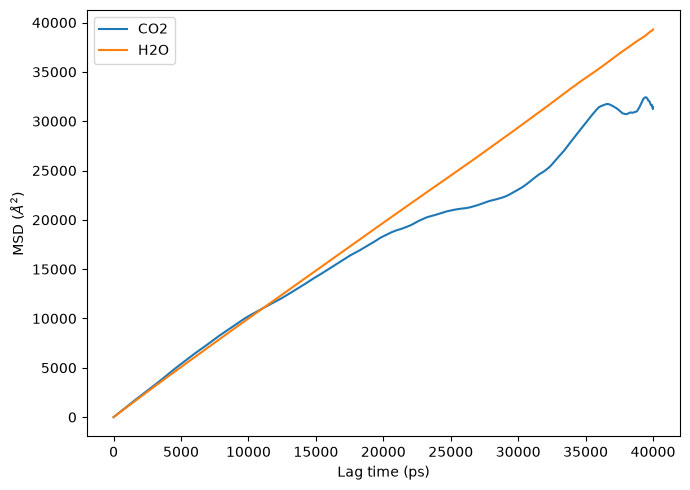

In [4]:
run_if(CO2_READY, r'''
co2_msd = EinsteinMSD(
    u1,
    select="resname CO2 and name C C_3",
    msd_type="xyz",
    fft=True,
).run()

water_msd = EinsteinMSD(
    u1,
    select="resname SOL and name OW",
    msd_type="xyz",
    fft=True,
).run()

lag_co2 = co2_msd.results.delta_t_values
msd_co2_A2 = co2_msd.results.timeseries
lag_water = water_msd.results.delta_t_values
msd_water_A2 = water_msd.results.timeseries

plt.figure(figsize=(7, 5))
plt.plot(lag_co2, msd_co2_A2, label="CO2")
plt.plot(lag_water, msd_water_A2, label="H2O")
plt.xlabel("Lag time (ps)")
plt.ylabel(r"MSD ($\AA^2$)")
plt.legend()
plt.tight_layout()
plt.show()

''', "Example 1 MSD")

## 📉 11. Example 1 — identify the diffusive regime and fit \(D\)


Plot the MSD on both **linear** and **log–log** axes. A useful local diagnostic is

$
\alpha(t)=\frac{d\ln(\mathrm{MSD})}{d\ln t}.
$

The preferred fitting region should satisfy, as closely as the data allow:

1. $\alpha$ $\approx 1$;
2. the MSD is approximately linear on linear axes;
3. the interval is beyond the short-time ballistic/transitional regime;
4. it is not so late that only a few time origins contribute;
5. modest changes in the fitting limits do not cause a large change in \(D\).


### 11.1 Inspect the diffusion regime and fit with MDAnalysis

The code below uses the MDAnalysis result generated in Section 10.6. First inspect the log–log MSD and local exponent $\alpha(t)$; only then choose the linear fitting interval.

<div class="msse-note"><b>💡 Student task</b><br>
Change <code>T_BEGIN</code> and <code>T_END</code> after inspecting the plots. Do not accept the example values automatically.</div>


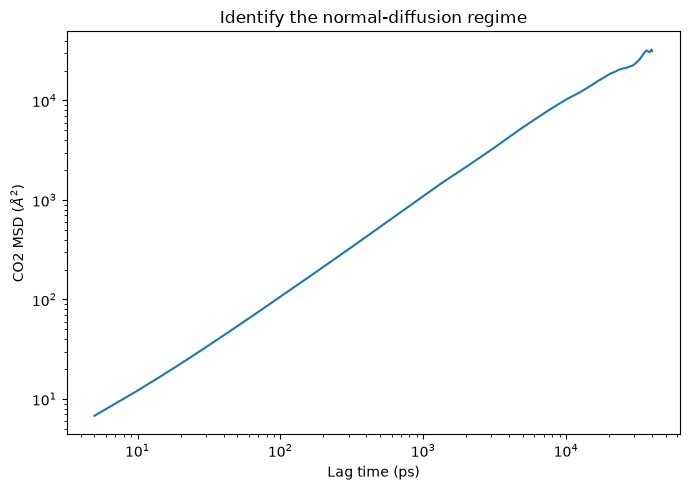

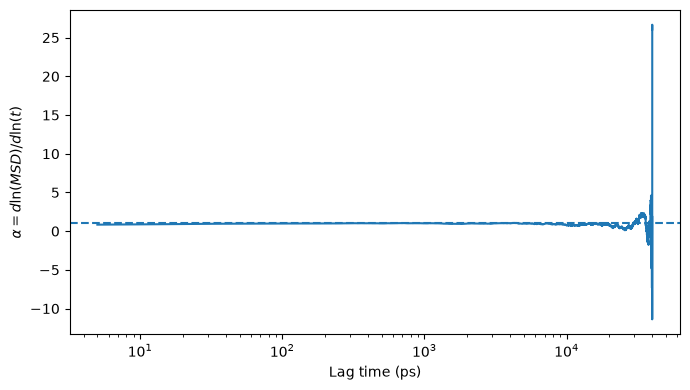

Fit slope = 1.10363 Å^2/ps
D_CO2 = 0.183938 Å^2/ps
D_CO2 = 1.83938e-09 m^2/s
Regression slope standard error = 0.00062 Å^2/ps


In [5]:
run_if(CO2_READY, r'''
mask = (lag_co2 > 0) & (msd_co2_A2 > 0)
log_t = np.log(lag_co2[mask])
log_msd = np.log(msd_co2_A2[mask])
alpha = np.gradient(log_msd, log_t)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(lag_co2[mask], msd_co2_A2[mask])
ax.set_xlabel("Lag time (ps)")
ax.set_ylabel(r"CO2 MSD ($\AA^2$)")
ax.set_title("Identify the normal-diffusion regime")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(lag_co2[mask], alpha)
ax.axhline(1.0, ls="--")
ax.set_xlabel("Lag time (ps)")
ax.set_ylabel(r"$\alpha=d\ln(MSD)/d\ln(t)$")
plt.tight_layout()
plt.show()

# EDIT THESE after inspecting the plots
T_BEGIN = 200.0   # ps
T_END = 1000.0    # ps

fit_mask = (lag_co2 >= T_BEGIN) & (lag_co2 <= T_END)
fit = linregress(lag_co2[fit_mask], msd_co2_A2[fit_mask])

D_A2_per_ps = fit.slope / (2 * co2_msd.dim_fac)
D_m2_per_s = D_A2_per_ps * 1e-8

print(f"Fit slope = {fit.slope:.6g} Å^2/ps")
print(f"D_CO2 = {D_A2_per_ps:.6g} Å^2/ps")
print(f"D_CO2 = {D_m2_per_s:.6g} m^2/s")
print(f"Regression slope standard error = {fit.stderr:.3g} Å^2/ps")

''', "Example 1 diffusion fit")

### 11.2 Optional GROMACS fitting cross-check

After choosing the interval independently, apply the same limits in `gmx msd` and compare the result with the Python fit.


```bash
gmx msd \
    -f ../production/prod.xtc \
    -s ../production/prod.tpr \
    -o msd_co2_fit.xvg \
    -mol diffusion_co2_molecules_fit.xvg \
    -sel "resname CO2" \
    -trestart 10 \
    -beginfit <T_BEGIN> \
    -endfit <T_END>
```


## 🔁 12. Example 1 — uncertainty and finite-size checks


### 12.1 Independent replicas

Repeat the production stage from independent initial velocity seeds while keeping the state point and force field identical.

```text
replicas/
├── rep01/
├── rep02/
├── rep03/
└── rep04/
```

Report the same fitting logic for every replica.

| Replica | $D_{\mathrm{CO2}}$ | 
|---|---:|
| 1 | 6.801831e-09 |
| 2 | 6.211994e-09 |
| 3 | 6.350702e-09 |
| Mean ± uncertainty | (6.454842 ± 0.308)e-09 |


#### Combine independent replicas with MDAnalysis

MDAnalysis exposes `results.msds_by_particle`, which makes it possible to pool particle-level MSD statistics across independent replicas. **Do not concatenate independent trajectories end-to-end**: the artificial jump between the last frame of one replica and the first frame of another corrupts the MSD.

The example below assumes each replica has already been converted to `prod_nojump.xtc` and uses the same saved-frame spacing.


In [ ]:
replica_dirs = [
    "CO2_water_diffusion/replicas/rep01",
    "CO2_water_diffusion/replicas/rep02",
    "CO2_water_diffusion/replicas/rep03",
]

replica_paths = [
    Path(folder) / name
    for folder in replica_dirs
    for name in ("prod.gro", "prod_nojump.xtc")
]
REPLICAS_READY = require_files("Example 1 replica pooling", *replica_paths)

run_if(REPLICAS_READY, r'''
replica_results = []
for folder in replica_dirs:
    ur = mda.Universe(f"{folder}/prod.gro", f"{folder}/prod_nojump.xtc")
    result = EinsteinMSD(
        ur,
        select="resname CO2 and name C",
        msd_type="xyz",
        fft=True,
    ).run()
    replica_results.append(result)

lag_ref = replica_results[0].results.delta_t_values
for result in replica_results[1:]:
    if not np.allclose(lag_ref, result.results.delta_t_values):
        raise ValueError("Replica lag-time grids differ.")

combined_particle_msds = np.concatenate(
    [r.results.msds_by_particle for r in replica_results], axis=1
)
average_replica_msd = combined_particle_msds.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(lag_ref, average_replica_msd)
plt.xlabel("Lag time (ps)")
plt.ylabel(r"Replica-pooled CO2 MSD ($\AA^2$)")
plt.tight_layout()
plt.show()

''', "Example 1 replica pooling")

### 12.2 Finite-size effect

For a cubic periodic bulk system, the Yeh–Hummer correction is

$$
D_{\infty}
=
D_L+
\frac{k_B T\xi}{6\pi\eta L},
$$

with $\xi\approx2.837297$.

Two routes are possible:

1. compare otherwise identical boxes of several sizes and examine $D$ versus $1/L$;
2. apply the analytical correction using an independently calculated or validated viscosity.

Do **not** carry this cubic bulk correction directly into the confined clay example.


### 12.3 Optional Green–Kubo cross-check

If velocities were stored sufficiently frequently:

```bash
gmx velacc \
    -f ../production/prod.trr \
    -s ../production/prod.tpr \
    -o vacf_co2.xvg \
    -mol
```

The Green–Kubo relation is

$$
D=\frac{1}{3}\int_0^\infty C_v(t)\,dt.
$$

Use this as a cross-check rather than as an automatic replacement for the MSD analysis. The velocity trajectory must be sampled much more finely than the VACF decay time.


# Example 2 — H₂ self-diffusion in bulk brine

The second example reuses the analysis discipline established with CO₂–water, but adds **salt and multiple mobile species**.

Main questions:

- How does H₂ mobility compare with the CO₂ example?
- Do H₂, water, Na⁺, and Cl⁻ reach their diffusive regimes on the same timescale?
- How can local ion/water structure help interpret a change in \(D_{\mathrm{H2}}\)?


## 🧂 13. Build and analyse H₂ in NaCl brine


### 13.1 Build the homogeneous H₂–brine box

```bash
cd H2_brine_diffusion/build

gmx insert-molecules \
    -ci ../inputs/H2.pdb \
    -o h2_box.gro \
    -nmol 10 \
    -box 4 4 4 \
    -seed 63563

gmx insert-molecules \
    -f h2_box.gro \
    -ci ../inputs/NA.pdb \
    -o h2_na.gro \
    -nmol 51 \
    -seed 87946

gmx insert-molecules \
    -f h2_na.gro \
    -ci ../inputs/CL.pdb \
    -o h2_nacl.gro \
    -nmol 51 \
    -seed 86646
```

For NaCl, use $N_{\mathrm{NA}}=N_{\mathrm{CL}}$. For other salts, the counts must respect stoichiometry and charge balance.


### 13.2 Create the H₂–brine topology and solvate

Create `build/topol_bulk.top`:

```text
#include "../inputs/oplsaa.ff/forcefield.itp"
#include "../inputs/H2.itp"
#include "../inputs/spce.itp"
#include "../inputs/ions.itp"

[ system ]
H2 in NaCl brine

[ molecules ]
H2     10
NA     51
CL     51
```

Then:

```bash
gmx solvate \
    -cp h2_nacl.gro \
    -cs spc216 \
    -o bulk_initial.gro \
    -p topol_bulk.top
```

For a 1:1 salt, the molality obtained from the final molecule counts is

$$
m_{\mathrm{NaCl}}
=
\frac{N_{\mathrm{NaCl}}}
{N_{\mathrm{water}}\times0.01801528}
\quad \mathrm{mol\,kg^{-1}}.
$$

Record the **actual** final composition rather than only the requested insertion counts.


### 13.3 Reuse the same MD workflow

Run the same sequence as Example 1:

```text
EM → NPT → NVT → NVE production
```

Use the corresponding `H2_brine_diffusion/` directories and H₂–brine topology.


### 13.3.1 Energy minimization

```bash
cd ../../H2_brine_diffusion/em

gmx grompp \
    -f ../inputs/em_diff.mdp \
    -c ../build/bulk_initial.gro \
    -p ../build/topol_bulk.top \
    -o em.tpr \
    -pp processed_em.top \
    -po mdout_em.mdp

gmx mdrun -deffnm em -v
```

> <span style="color:#27AE60"><b>✅ Validation:</b></span> No fatal topology errors, correct total charge, sensible atom count, and acceptable force convergence.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not use `-maxwarn` to bypass a real topology/composition inconsistency.


### 13.3.2 NPT equilibration

```bash
cd ../equilibration

gmx grompp \
    -f ../inputs/npt_diff.mdp \
    -c ../em/em.gro \
    -p ../build/topol_bulk.top \
    -o npt.tpr \
    -pp processed_npt.top \
    -po mdout_npt.mdp

gmx mdrun -deffnm npt -v
```



### 13.3.3 NVT equilibration at the equilibrated density

```bash
gmx grompp \
    -f ../inputs/nvt_diff.mdp \
    -c npt.gro \
    -t npt.cpt \
    -p ../build/topol_bulk.top \
    -o nvt.tpr \
    -pp processed_nvt.top \
    -po mdout_nvt.mdp

gmx mdrun -deffnm nvt -v
```

> 🎯 **Purpose:** stabilize the final box dimensions before removing thermostat and barostat coupling.


### 13.3.4 NVE production

The production MDP should retain the validated force field, PME/cutoff settings, constraints, and timestep, but use:

```text
tcoupl       = no
pcoupl       = no
continuation = yes
gen_vel      = no
```

Run:

```bash
cd ../production

gmx grompp \
    -f ../inputs/nve_diff.mdp \
    -c ../equilibration/nvt.gro \
    -t ../equilibration/nvt.cpt \
    -p ../build/topol_bulk.top \
    -o prod.tpr \
    -pp processed_prod.top \
    -po mdout_prod.mdp

gmx mdrun -deffnm prod -v
```

> <span style="color:#27AE60"><b>✅ Validation:</b></span> Check total-energy conservation, temperature drift, constraint failures, and uninterrupted simulation time.


### 13.4 Calculate H₂, water, and ion self-diffusion

Run:

```bash
cd ../analysis

gmx msd -f ../production/prod.xtc -s ../production/prod.tpr \
    -o msd_h2.xvg -mol diffusion_h2_molecules.xvg \
    -sel "resname H2" -trestart 10

gmx msd -f ../production/prod.xtc -s ../production/prod.tpr \
    -o msd_water.xvg -mol diffusion_water_molecules.xvg \
    -sel "resname SOL" -trestart 10

gmx msd -f ../production/prod.xtc -s ../production/prod.tpr \
    -o msd_na.xvg -sel "resname NA" -trestart 10

gmx msd -f ../production/prod.xtc -s ../production/prod.tpr \
    -o msd_cl.xvg -sel "resname CL" -trestart 10
```

Apply the **same regime-identification and fitting-window test** used in Example 1 to each species separately.


### 13.5 Connect structure to mobility

Use RDFs to examine the local environment around H₂.

```bash
gmx rdf \
    -f ../production/prod.xtc \
    -s ../production/prod.tpr \
    -o rdf_h2_water.xvg \
    -cn cn_h2_water.xvg \
    -ref "mol_com of resname H2" \
    -sel "name OW and resname SOL"

gmx rdf \
    -f ../production/prod.xtc \
    -s ../production/prod.tpr \
    -o rdf_h2_ions.xvg \
    -ref "mol_com of resname H2" \
    -sel "resname NA; resname CL"
```

Questions:

- Does salt reduce only H₂ mobility, or also water mobility?
- Are Na⁺ and Cl⁻ equally mobile?
- Do changes in RDF peak positions/intensities support a plausible solvation-based interpretation?
- Is the observed trend robust across replicas?

<div class="msse-note"><b>💡 Interpretation</b><br>
An RDF demonstrates spatial correlation, not causation. Use it to support a mechanistic interpretation, not to claim automatically that a stronger peak caused a lower diffusivity.</div>


#### 13.5.1 Interactive RDF analysis with MDAnalysis

`InterRDF` calculates atom-group radial distribution functions while accounting for periodic boundaries through the minimum-image convention. This is useful for testing how the local water/ion environment changes around H₂.

The example below is **atom-based** for the supplied H₂ selection. If the final H₂ model contains a dedicated molecular centre/interaction site, select that site instead when a molecular-centre RDF is desired.


In [ ]:
u2 = mda.Universe(
    "H2_brine_diffusion/production/prod.tpr",
    "H2_brine_diffusion/production/prod.xtc",
)

h2_atoms = u2.select_atoms("resname H2 and name H")
water_o = u2.select_atoms("resname SOL and name OW")
na = u2.select_atoms("resname NA")
cl = u2.select_atoms("resname CL")

print("H2 atoms:", h2_atoms.n_atoms)
print("Water O atoms:", water_o.n_atoms)
print("Na+ atoms:", na.n_atoms)
print("Cl- atoms:", cl.n_atoms)

rdf_h2_water = InterRDF(h2_atoms, water_o, nbins=150, range=(0.0, 12.0)).run()
rdf_h2_na = InterRDF(h2_atoms, na, nbins=150, range=(0.0, 12.0)).run()
rdf_h2_cl = InterRDF(h2_atoms, cl, nbins=150, range=(0.0, 12.0)).run()

plt.figure(figsize=(7, 5))
plt.plot(rdf_h2_water.results.bins, rdf_h2_water.results.rdf, label="H2–OW")
plt.plot(rdf_h2_na.results.bins, rdf_h2_na.results.rdf, label="H2–Na+")
plt.plot(rdf_h2_cl.results.bins, rdf_h2_cl.results.rdf, label="H2–Cl−")
plt.xlabel(r"r ($\AA$)")
plt.ylabel("g(r)")
plt.legend()
plt.tight_layout()
plt.show()


# Example 3 — H₂ diffusion in a water-filled clay slit pore

The third example changes the physics qualitatively. The fluid is no longer homogeneous and diffusion is no longer isotropic.


Assume the clay surfaces are parallel to the $x$-$y$ plane and the pore normal is $z$ with 8 nm pore width.


## 🧱 14. Confined diffusion: parallel, perpendicular, and spatial heterogeneity


### 14.0.1 Energy minimization

```bash
cd ../../H2_clay_diffusion/em

gmx grompp \
    -f ../inputs/em_diff.mdp \
    -c ../build/preem.solvate.gro \
    -p ../build/topol_bulk.top \
    -o em.tpr \
    -pp processed_em.top \
    -po mdout_em.mdp

gmx mdrun -deffnm em -v
```

> <span style="color:#27AE60"><b>✅ Validation:</b></span> No fatal topology errors, correct total charge, sensible atom count, and acceptable force convergence.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not use `-maxwarn` to bypass a real topology/composition inconsistency.


### 14.0.2 NPT equilibration

```bash
cd ../equilibration

gmx grompp \
    -f ../inputs/npt_diff.mdp \
    -c ../em/em.gro \
    -p ../build/topol_bulk.top \
    -o npt.tpr \
    -r ../inputs/preem.gro \
    -maxwarn 5 \
    -pp processed_npt.top \
    -po mdout_npt.mdp

gmx mdrun -deffnm npt -v
```



### 14.0.3 NVT equilibration at the equilibrated density

```bash
gmx grompp \
    -f ../inputs/nvt_diff.mdp \
    -c npt.gro \
    -t npt.cpt \
    -p ../build/topol_bulk.top \
    -o nvt.tpr \
    -r ../inputs/preem.gro \
    -maxwarn 5 \
    -pp processed_nvt.top \
    -po mdout_nvt.mdp

gmx mdrun -deffnm nvt -v
```


### 14.0.4 NVE production for confined self-diffusion

Use the fixed pore geometry and equilibrated state as the starting point for an NVE production trajectory:

```bash
cd ../production

gmx grompp \
    -f ../inputs/nve_diff.mdp \
    -c ../equilibration/nvt.gro \
    -t ../equilibration/nvt.cpt \
    -p ../build/topol_bulk.top \
    -o prod.tpr \
    -r ../inputs/preem.gro \
    -pp processed_prod.top \
    -po mdout_prod.mdp

gmx mdrun -deffnm prod -v
```

> <span style="color:#27AE60"><b>✅ Validation:</b></span> Check total-energy conservation before using the trajectory for diffusion.


### 14.1 Create an index for H₂ and water
    
Create the index:

```bash
gmx make_ndx \
    -f ../equilibration/nvt.gro \
    -o groups.ndx
```

At the `make_ndx` prompt:

```text
r H2
r SOL
q
```

The resulting `groups.ndx` contains separate groups for H₂, water, and the clay framework.

### 14.1 Verify the pore orientation and molecular layering

Before calculating diffusion, inspect the system visually and calculate number-density profiles along $z$.

Create an index containing at least H₂ and water, then run:

```bash
cd H2_clay_diffusion/analysis

gmx density \
    -f ../equilibration/nvt.xtc \
    -s ../equilibration/nvt.tpr \
    -n groups.ndx \
    -o density_z.xvg \
    -d Z \
    -sl 200 \
    -dens number \
    -ng 2
```

The density profiles identify surface layers and the pore centre, and show immediately why a single bulk-like diffusivity may be inadequate.

```bash

gmx density \
    -f ../equilibration/nvt.xtc \
    -s ../equilibration/nvt.tpr \
    -n groups.ndx \
    -o density_z_late.xvg \
    -b 50000 \
    -d Z \
    -sl 200 \
    -dens number \
    -ng 2
```


#### 14.1.1 Density profiles with MDAnalysis `LinearDensity`

`LinearDensity` provides mass-density profiles along the Cartesian axes. For residue grouping, positions are based on molecular COMs. Because this analysis assumes a fixed orthorhombic volume, use the fixed-volume NVT trajectory (or another demonstrably fixed-volume trajectory).


In [ ]:
u3_density = mda.Universe(
    "H2_clay_diffusion/production/prod.tpr",
    "H2_clay_diffusion/production/prod.xtc",
)

h2_3 = u3_density.select_atoms("resname H2")
water_3 = u3_density.select_atoms("resname SOL")

ld_h2 = LinearDensity(h2_3, grouping="residues", binsize=0.5).run()
ld_water = LinearDensity(water_3, grouping="residues", binsize=0.5).run()

edges_h2 = ld_h2.results.z.hist_bin_edges
z_h2 = 0.5 * (edges_h2[:-1] + edges_h2[1:])
rho_h2 = ld_h2.results.z.mass_density

edges_w = ld_water.results.z.hist_bin_edges
z_w = 0.5 * (edges_w[:-1] + edges_w[1:])
rho_w = ld_water.results.z.mass_density

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
axes[0].plot(z_h2, rho_h2)
axes[0].set_ylabel(r"H2 mass density (g cm$^{-3}$)")
axes[1].plot(z_w, rho_w)
axes[1].set_ylabel(r"Water mass density (g cm$^{-3}$)")
axes[1].set_xlabel(r"z ($\AA$)")
plt.show()


Save the following as `analysis/plot_density.py` if a quick plot is useful:

```python

import numpy as np
import matplotlib.pyplot as plt


def load_xvg(filename):
    data = []

    with open(filename, encoding="utf-8") as file:
        for line in file:
            if line.startswith(("#", "@")) or not line.strip():
                continue
            data.append([float(value) for value in line.split()])

    return np.asarray(data)


data = load_xvg("density_z.xvg")

z = data[:, 0]
density_h2 = data[:, 1]
density_water = data[:, 2]

fig, axes = plt.subplots(
    2, 1,
    figsize=(9, 9),
    sharex=True,
    constrained_layout=True
)

profiles = [
    (density_h2, "H₂", "tab:blue"),
    (density_water, "Water", "tab:green"),
]

for ax, (density, label, color) in zip(axes, profiles):
    ax.plot(z, density, color=color, linewidth=2)
    ax.set_ylabel("Number density\n(nm$^{-3}$)")
    ax.set_title(label)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("z (nm)")

fig.suptitle("Density profiles across the clay pore")
plt.show()
```

### 14.2 Diffusion parallel to the clay surfaces

For a wall normal to $z$, the lateral option uses motion in the $x$-$y$ plane:

```bash
gmx msd \
    -f ../production/prod.xtc \
    -s ../production/prod.tpr \
    -o msd_h2_parallel.xvg \
    -mol diffusion_h2_parallel.xvg \
    -sel "resname H2" \
    -lateral z \
    -trestart 10
```

For normal in-plane diffusion,

$$
D_{\parallel}
=
\frac{1}{4}
\frac{d\langle\Delta x^2+\Delta y^2\rangle}{dt}.
$$

Identify the in-plane normal-diffusion interval before accepting the fitted value.


### 14.3 Motion perpendicular to the surfaces

```bash
gmx msd \
    -f ../production/prod.xtc \
    -s ../production/prod.tpr \
    -o msd_h2_z.xvg \
    -mol diffusion_h2_z_molecules.xvg \
    -sel "resname H2" \
    -type z \
    -trestart 10
```

For an **unbounded** one-dimensional diffusive coordinate,

$$
D_z=\frac{1}{2}\frac{d\langle\Delta z^2\rangle}{dt}.
$$

However, a closed slit pore is bounded in $z$. At sufficiently long times, the transverse MSD can plateau because molecules cannot diffuse indefinitely through the walls.


### 14.4 Molecular-COM anisotropy with MDAnalysis

For a two-site H₂ model, use the molecular COM rather than treating the two H atoms as independent diffusing particles. First create a no-jump NVE trajectory:

```bash
cd H2_clay_diffusion/analysis

gmx trjconv \
    -s ../production/prod.tpr \
    -f ../production/prod.xtc \
    -o prod_nojump.xtc \
    -pbc nojump
```

The Python helper from Section 7.3 can then calculate separate in-plane and transverse COM MSDs.


In [ ]:
CLAY_RAW_READY = require_files(
    "Example 3 production trajectory",
    "H2_clay_diffusion/production/prod.tpr",
    "H2_clay_diffusion/production/prod.xtc",
)
CLAY_MSD_READY = CLAY_RAW_READY and require_files(
    "Example 3 no-jump trajectory",
    "H2_clay_diffusion/analysis/prod_nojump.xtc",
)

run_if(CLAY_MSD_READY, r'''
u3 = mda.Universe(
    "H2_clay_diffusion/production/prod.tpr",
    "H2_clay_diffusion/analysis/prod_nojump.xtc",
)

t3, h2_com_3 = collect_residue_coms(u3, "resname H2")
max_lag = len(t3) // 2
lag3 = t3[1:max_lag + 1] - t3[0]

msd_xy = windowed_msd(h2_com_3, dims=(0, 1), max_lag=max_lag)
msd_z = windowed_msd(h2_com_3, dims=(2,), max_lag=max_lag)

plt.figure(figsize=(7, 5))
plt.plot(lag3, msd_xy, label=r"parallel: $x,y$")
plt.plot(lag3, msd_z, label=r"perpendicular: $z$")
plt.xlabel("Lag time (ps)")
plt.ylabel(r"H2 COM MSD ($\AA^2$)")
plt.legend()
plt.tight_layout()
plt.show()

''', "Example 3 anisotropic MSD")

### 14.5 Dynamic spatial selections

An **updating selection** is recalculated every frame. It is useful for asking questions such as “how many H₂ molecules are currently close to the lower clay surface?”

Set the spatial limits only after examining the density profile. MDAnalysis coordinates are in Å.


In [15]:
# Example limits only — replace using the density profile for the supplied clay system.
Z_NEAR_MIN = 20.0   # Å
Z_NEAR_MAX = 40.0   # Å

run_if(CLAY_RAW_READY, r'''
u3_dynamic = mda.Universe(
    "H2_clay_diffusion/production/prod.tpr",
    "H2_clay_diffusion/production/prod.xtc",
)

near_surface = u3_dynamic.select_atoms(
    f"resname H2 and prop z >= {Z_NEAR_MIN} and prop z < {Z_NEAR_MAX}",
    updating=True,
)

for ts in u3_dynamic.trajectory[::100]:
    print(f"t = {ts.time:8.1f} ps : {len(near_surface.residues):3d} H2 molecules in region")

''', "Example 3 dynamic selection")

t =      0.0 ps :   9 H2 molecules in region
t =    100.0 ps :   7 H2 molecules in region
t =    200.0 ps :   9 H2 molecules in region
t =    300.0 ps :  10 H2 molecules in region
t =    400.0 ps :   9 H2 molecules in region
t =    500.0 ps :   9 H2 molecules in region
t =    600.0 ps :   6 H2 molecules in region
t =    700.0 ps :   9 H2 molecules in region
t =    800.0 ps :   7 H2 molecules in region
t =    900.0 ps :   7 H2 molecules in region
t =   1000.0 ps :  10 H2 molecules in region
t =   1100.0 ps :   9 H2 molecules in region
t =   1200.0 ps :  11 H2 molecules in region
t =   1300.0 ps :   9 H2 molecules in region
t =   1400.0 ps :   9 H2 molecules in region
t =   1500.0 ps :  14 H2 molecules in region
t =   1600.0 ps :  11 H2 molecules in region
t =   1700.0 ps :  12 H2 molecules in region
t =   1800.0 ps :  10 H2 molecules in region
t =   1900.0 ps :  10 H2 molecules in region
t =   2000.0 ps :   8 H2 molecules in region
t =   2100.0 ps :  11 H2 molecules in region
t =   2200

### 14.6 Residence / survival probability near a surface

For a stronger confinement diagnostic, track molecular identities rather than only the instantaneous number of molecules in a layer. The simple implementation below calculates a **continuous survival probability**: a molecule contributes at lag time $t$ only if it was present at the time origin and remained continuously in the selected layer up to that lag.

This complements the transverse MSD, which can plateau simply because the pore is bounded.


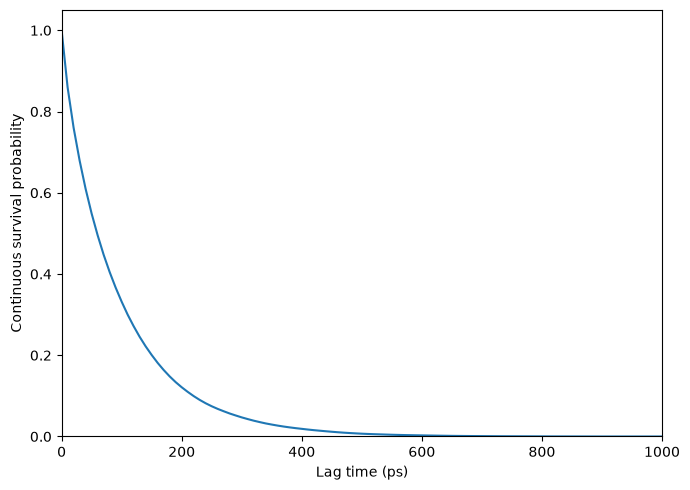

In [16]:
def occupancy_from_com(universe, selection, zmin, zmax, step=10):
    group = universe.select_atoms(selection)
    times, occupancy = [], []
    universe.trajectory.rewind()
    for ts in universe.trajectory[::step]:
        z = group.center_of_mass(compound="residues")[:, 2]
        times.append(ts.time)
        occupancy.append((z >= zmin) & (z < zmax))
    return np.asarray(times), np.asarray(occupancy, dtype=bool)


def continuous_survival(occupancy, max_lag=None):
    nframes, nmol = occupancy.shape
    if max_lag is None:
        max_lag = nframes // 3

    P = np.full(max_lag + 1, np.nan)
    P[0] = 1.0

    for lag in range(1, max_lag + 1):
        values = []
        for t0 in range(nframes - lag):
            initial = occupancy[t0]
            n0 = initial.sum()
            if n0 == 0:
                continue
            stayed = initial & np.all(occupancy[t0:t0 + lag + 1], axis=0)
            values.append(stayed.sum() / n0)
        if values:
            P[lag] = np.mean(values)
    return P

run_if(CLAY_RAW_READY, r'''
u3_res = mda.Universe(
    "H2_clay_diffusion/production/prod.tpr",
    "H2_clay_diffusion/production/prod.xtc",
)

t_occ, occ = occupancy_from_com(
    u3_res, "resname H2", Z_NEAR_MIN, Z_NEAR_MAX, step=10
)
P = continuous_survival(occ)
lag_res = np.arange(len(P)) * (t_occ[1] - t_occ[0])

plt.figure(figsize=(7, 5))
plt.plot(lag_res, P)
plt.xlabel("Lag time (ps)")
plt.ylabel("Continuous survival probability")
plt.ylim(0, 1.05)
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

''', "Example 3 residence analysis")

In [17]:
# Example limits only — replace using the density profile for the supplied clay system.
Z_NEAR_MIN = 40.0   # Å
Z_NEAR_MAX = 60.0   # Å

run_if(CLAY_RAW_READY, r'''
u3_dynamic = mda.Universe(
    "H2_clay_diffusion/production/prod.tpr",
    "H2_clay_diffusion/production/prod.xtc",
)

near_surface = u3_dynamic.select_atoms(
    f"resname H2 and prop z >= {Z_NEAR_MIN} and prop z < {Z_NEAR_MAX}",
    updating=True,
)

for ts in u3_dynamic.trajectory[::100]:
    print(f"t = {ts.time:8.1f} ps : {len(near_surface.residues):3d} H2 molecules in region")

''', "Example 3 dynamic selection")

t =      0.0 ps :   7 H2 molecules in region
t =    100.0 ps :  12 H2 molecules in region
t =    200.0 ps :  12 H2 molecules in region
t =    300.0 ps :  11 H2 molecules in region
t =    400.0 ps :   7 H2 molecules in region
t =    500.0 ps :   8 H2 molecules in region
t =    600.0 ps :  13 H2 molecules in region
t =    700.0 ps :  11 H2 molecules in region
t =    800.0 ps :  11 H2 molecules in region
t =    900.0 ps :  11 H2 molecules in region
t =   1000.0 ps :   7 H2 molecules in region
t =   1100.0 ps :  10 H2 molecules in region
t =   1200.0 ps :  11 H2 molecules in region
t =   1300.0 ps :  14 H2 molecules in region
t =   1400.0 ps :  15 H2 molecules in region
t =   1500.0 ps :   9 H2 molecules in region
t =   1600.0 ps :  12 H2 molecules in region
t =   1700.0 ps :   8 H2 molecules in region
t =   1800.0 ps :  16 H2 molecules in region
t =   1900.0 ps :  13 H2 molecules in region
t =   2000.0 ps :  15 H2 molecules in region
t =   2100.0 ps :   9 H2 molecules in region
t =   2200

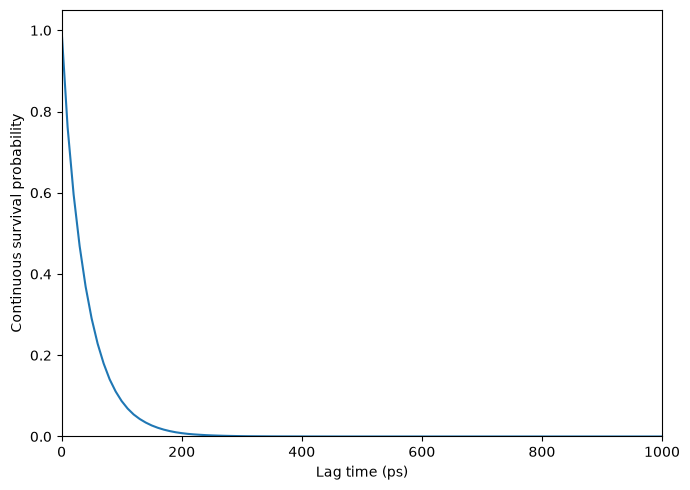

In [18]:
def occupancy_from_com(universe, selection, zmin, zmax, step=10):
    group = universe.select_atoms(selection)
    times, occupancy = [], []
    universe.trajectory.rewind()
    for ts in universe.trajectory[::step]:
        z = group.center_of_mass(compound="residues")[:, 2]
        times.append(ts.time)
        occupancy.append((z >= zmin) & (z < zmax))
    return np.asarray(times), np.asarray(occupancy, dtype=bool)


def continuous_survival(occupancy, max_lag=None):
    nframes, nmol = occupancy.shape
    if max_lag is None:
        max_lag = nframes // 3

    P = np.full(max_lag + 1, np.nan)
    P[0] = 1.0

    for lag in range(1, max_lag + 1):
        values = []
        for t0 in range(nframes - lag):
            initial = occupancy[t0]
            n0 = initial.sum()
            if n0 == 0:
                continue
            stayed = initial & np.all(occupancy[t0:t0 + lag + 1], axis=0)
            values.append(stayed.sum() / n0)
        if values:
            P[lag] = np.mean(values)
    return P

run_if(CLAY_RAW_READY, r'''
u3_res = mda.Universe(
    "H2_clay_diffusion/production/prod.tpr",
    "H2_clay_diffusion/production/prod.xtc",
)

t_occ, occ = occupancy_from_com(
    u3_res, "resname H2", Z_NEAR_MIN, Z_NEAR_MAX, step=10
)
P = continuous_survival(occ)
lag_res = np.arange(len(P)) * (t_occ[1] - t_occ[0])

plt.figure(figsize=(7, 5))
plt.plot(lag_res, P)
plt.xlabel("Lag time (ps)")
plt.ylabel("Continuous survival probability")
plt.ylim(0, 1.05)
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

''', "Example 3 residence analysis")

# Example 4 — collective diffusion in a bulk gas mixture

The final example moves from **tagged-particle self-diffusion** to **collective species motion**.

For the core practical, use a binary bulk **H₂–CO₂** mixture.


## 15.0 Build the H₂–CO₂ bulk mixture

Use the same sequential build style as the earlier examples. Run these commands from the Example 4 build directory:

```bash
cd multicomponent_bulk_diffusion/build

gmx insert-molecules -ci ../inputs/CO2.pdb -o Box1.gro -nmol 1000 -box 4.5 4.5 4.5
gmx insert-molecules -f Box1.gro -ci ../inputs/H2.pdb -o Box2.gro -nmol 1000

cd ../em

gmx grompp -f ../inputs/em_diff.mdp -c ../build/Box2.gro -p ../build/topol.top -o em.tpr
gmx mdrun -deffnm em -v

cd ../equilibration
gmx grompp -f ../inputs/npt_diff.mdp -c ../em/em.gro -p ../build/topol.top -o npt.tpr
gmx mdrun -deffnm npt -v

gmx grompp -f ../inputs/nvt_diff.mdp -c ../equilibration/npt.gro -p ../build/topol.top -o nvt.tpr
gmx mdrun -deffnm nvt -v

cd ../production
gmx grompp -f ../inputs/nve_diff.mdp -c ../equilibration/nvt.gro -t ../equilibration/nvt.cpt -p ../build/topol.top -o prod.tpr
gmx mdrun -deffnm prod -v
```

## 🔄 15. Maxwell–Stefan diffusion from collective molecular displacement


### 15.1 First calculate the two self-diffusion coefficients

```bash
cd ../analysis

gmx msd -f ../production/prod.xtc -s ../production/prod.tpr \
    -o msd_h2.xvg -mol diffusion_h2_molecules.xvg \
    -sel "resname H2" -trestart 10

gmx msd -f ../production/prod.xtc -s ../production/prod.tpr \
    -o msd_co2.xvg -mol diffusion_co2_molecules.xvg \
    -sel "resname CO2" -trestart 10
```

These are **not** the Maxwell–Stefan coefficient. They describe tagged H₂ and tagged CO₂ motion.


### 15.2 Collective displacement correlations

For species $i$, define its collective displacement over lag time $t$:

$$
\mathbf S_i(t;t_0)
=
\sum_{k=1}^{N_i}
\left[
\mathbf r_{ik}(t_0+t)-\mathbf r_{ik}(t_0)
\right].
$$

The Onsager displacement coefficients used in this tutorial are obtained from the long-time slopes:

$$
\Lambda_{ij}
=
\frac{1}{6N}
\frac{d}{dt}
\left\langle
\mathbf S_i(t)\cdot\mathbf S_j(t)
\right\rangle,
$$

where $N=N_1+N_2$ for the binary mixture.

For a binary system,

$$
\widetilde D_{12}
=
\frac{x_2}{x_1}\Lambda_{11}
+
\frac{x_1}{x_2}\Lambda_{22}
-
2\Lambda_{12}.
$$

This is a collective transport coefficient and can differ substantially from either self-diffusion coefficient.


### 15.3 Obtain molecular COM trajectories with MDAnalysis

First create a no-jump trajectory:

```bash
gmx trjconv \
    -s ../production/prod.tpr \
    -f ../production/prod.xtc \
    -o prod_nojump.xtc \
    -pbc nojump
```

Instead of exporting thousands of COM coordinates to separate `.xvg` files, MDAnalysis can read the GROMACS trajectory directly and calculate one COM vector per molecule at every frame.


In [19]:
u4 = mda.Universe(
    "multicomponent_bulk_diffusion/production/prod.tpr",
    "multicomponent_bulk_diffusion/analysis/prod_nojump.xtc",
)

t_h2, r_h2 = collect_residue_coms(u4, "resname H2")
t_co2, r_co2 = collect_residue_coms(u4, "resname CO2")

if not np.allclose(t_h2, t_co2):
    raise ValueError("H2 and CO2 time grids do not match.")

print("H2 COM array:", r_h2.shape, "[frames, molecules, xyz]")
print("CO2 COM array:", r_co2.shape, "[frames, molecules, xyz]")


H2 COM array: (8001, 1000, 3) [frames, molecules, xyz]
CO2 COM array: (8001, 1000, 3) [frames, molecules, xyz]


### 15.4 Calculate $\Lambda_{ij}$ and $\widetilde D_{12}$ in Python

The collective displacement functions are calculated directly from the molecular COM arrays. As with ordinary MSD, the collective correlation curves must be inspected before selecting a linear fitting interval.

For positions read by MDAnalysis, the slopes and resulting coefficients are in Å²/ps.


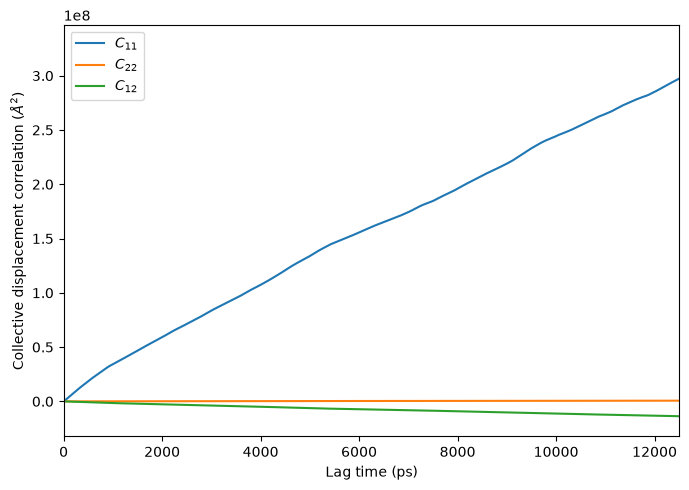

Lambda11 = 2.80512 Å^2/ps
Lambda22 = 0.00597851 Å^2/ps
Lambda12 = -0.129072 Å^2/ps
Maxwell-Stefan D12 = 3.06924 Å^2/ps
Maxwell-Stefan D12 = 3.06924e-08 m^2/s


In [21]:
def collective_correlations(pos_i, pos_j, max_lag=None):
    nframes = pos_i.shape[0]
    if max_lag is None:
        max_lag = nframes // 2

    corr = np.empty(max_lag, dtype=float)
    for lag in range(1, max_lag + 1):
        di = pos_i[lag:] - pos_i[:-lag]
        dj = pos_j[lag:] - pos_j[:-lag]
        Si = di.sum(axis=1)
        Sj = dj.sum(axis=1)
        corr[lag - 1] = np.mean(np.sum(Si * Sj, axis=1))
    return corr

max_lag = len(t_h2) // 2
lags = t_h2[1:max_lag + 1] - t_h2[0]

C11 = collective_correlations(r_h2, r_h2, max_lag)
C22 = collective_correlations(r_co2, r_co2, max_lag)
C12 = collective_correlations(r_h2, r_co2, max_lag)

plt.figure(figsize=(7, 5))
plt.plot(lags, C11, label=r"$C_{11}$")
plt.plot(lags, C22, label=r"$C_{22}$")
plt.plot(lags, C12, label=r"$C_{12}$")
plt.xlim(0, 12500)
plt.xlabel("Lag time (ps)")
plt.ylabel(r"Collective displacement correlation ($\AA^2$)")
plt.legend()
plt.tight_layout()
plt.show()

# EDIT THESE after inspecting the collective-correlation curves.
T_BEGIN_MS = 200.0  # ps
T_END_MS = 1000.0   # ps
fit = (lags >= T_BEGIN_MS) & (lags <= T_END_MS)

s11 = linregress(lags[fit], C11[fit]).slope
s22 = linregress(lags[fit], C22[fit]).slope
s12 = linregress(lags[fit], C12[fit]).slope

N1 = r_h2.shape[1]
N2 = r_co2.shape[1]
N = N1 + N2
x1 = N1 / N
x2 = N2 / N

L11 = s11 / (6 * N)
L22 = s22 / (6 * N)
L12 = s12 / (6 * N)

D12_MS_A2_ps = (x2 / x1) * L11 + (x1 / x2) * L22 - 2 * L12
D12_MS_m2_s = D12_MS_A2_ps * 1e-8

print(f"Lambda11 = {L11:.6g} Å^2/ps")
print(f"Lambda22 = {L22:.6g} Å^2/ps")
print(f"Lambda12 = {L12:.6g} Å^2/ps")
print(f"Maxwell-Stefan D12 = {D12_MS_A2_ps:.6g} Å^2/ps")
print(f"Maxwell-Stefan D12 = {D12_MS_m2_s:.6g} m^2/s")


### 15.5 What about Fick diffusion?

The Maxwell–Stefan coefficient captures collective friction/relative motion. Converting to a Fick diffusivity requires the appropriate **thermodynamic factor** for the non-ideal mixture.

That additional thermodynamic calculation is intentionally separated from this core exercise. The key learning outcome here is that:

$$
D^{self}_i
\neq
\widetilde D_{ij}
\neq
D^{F}_{ij}
$$

in general.


# References and documentation

Scientific basis used to structure this tutorial:

- Einstein–Smoluchowski relation for self-diffusion from MSD.
- Green–Kubo relation for self-diffusion from the velocity autocorrelation function.
- Maginn, Messerly, Carlson, Roe & Elliot (2019), best-practice guidance for transport properties from molecular simulation.
- Yeh & Hummer (2004), periodic finite-size correction for bulk self-diffusion.
- The diffusion section of the MSSE molecular-modelling review used in development of this summer-school material, including self-, Maxwell–Stefan-, Fick-, and confined-diffusion considerations.

GROMACS documentation to verify against the pinned teaching version:

- `gmx insert-molecules`
- `gmx solvate`
- `gmx msd`
- `gmx trajectory`
- `gmx density`
- `gmx rdf`
- `gmx velacc`

MDAnalysis documentation used for the Python analysis layer:

- MDAnalysis User Guide — Quick Start
- `MDAnalysis.analysis.msd.EinsteinMSD`
- `MDAnalysis.analysis.rdf.InterRDF`
- `MDAnalysis.analysis.lineardensity.LinearDensity`
- `MDAnalysis.transformations.nojump.NoJump`

### What MDAnalysis adds to each example

| Example | MDAnalysis capability used |
|---|---|
| CO₂–water | trajectory loading, selections, windowed MSD, log–log diagnostics, fitting, replica pooling |
| H₂–brine | selections and RDFs linking local structure to mobility |
| H₂–clay | residue COMs, anisotropic MSD, linear density, updating selections, survival probability |
| H₂–CO₂ | molecular COM trajectories and custom collective/Onsager correlations |
